In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
titanic = pd.read_csv('Titanic-Dataset.csv')

In [ ]:
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
titanic.shape

(891, 12)

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)

/tmp/ipykernel_3340/2184073557.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(), inplace=True)


In [ ]:
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


In [ ]:
titanic.drop('Cabin', axis=1, inplace=True)

No strong linear relationship is visible between age and fare; points are scattered widely, though most high-fare points cluster among passengers aged 20–50.

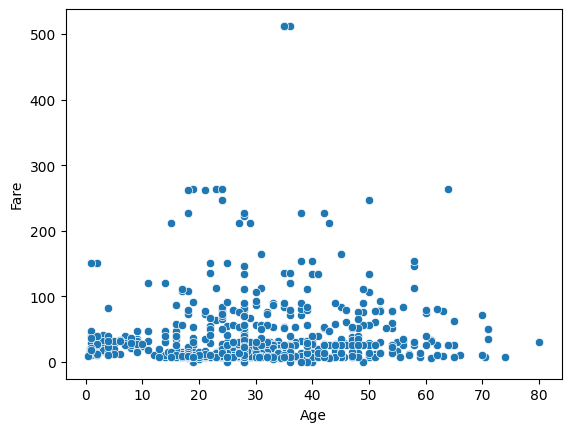

In [ ]:
sns.scatterplot(data=titanic, x="Age", y="Fare")
plt.show()

Survival rate drops sharply from 1st to 3rd class — 1st class passengers survived at a much higher rate than 3rd class, where the majority did not survive.

<Axes: xlabel='Pclass', ylabel='count'>

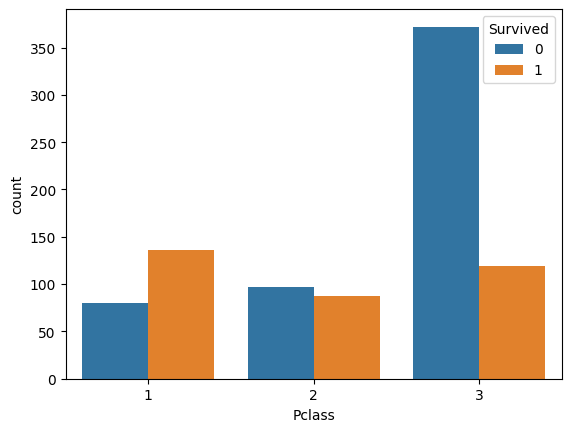

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=titanic)

Fare shows a mild positive correlation with Survived, while Pclass shows a negative correlation with both Fare and Survived

<Axes: >

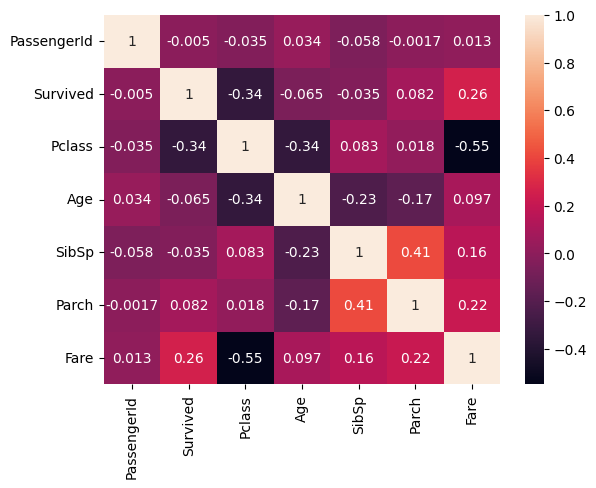

In [ ]:
sns.heatmap(titanic.corr(numeric_only=True), annot=True)

Fare is heavily right-skewed, with the majority of passengers paying under 50, but a long tail of high fares  pulling the mean well above the median.

<Axes: xlabel='Fare', ylabel='Count'>

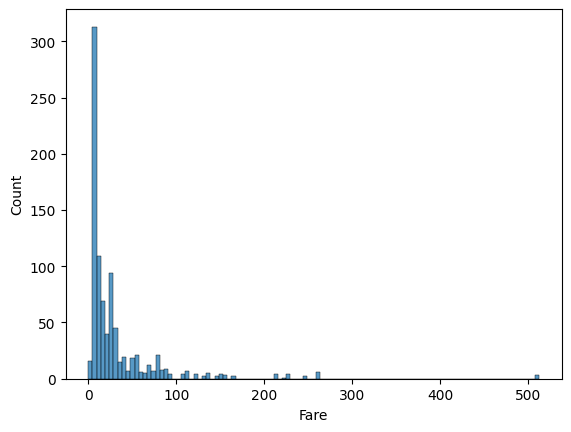

In [ ]:
sns.histplot(data=titanic, x="Fare")

Age is roughly bell-shaped but slightly right-skewed, with most passengers between 20–40 years.


<Axes: xlabel='Age', ylabel='Count'>

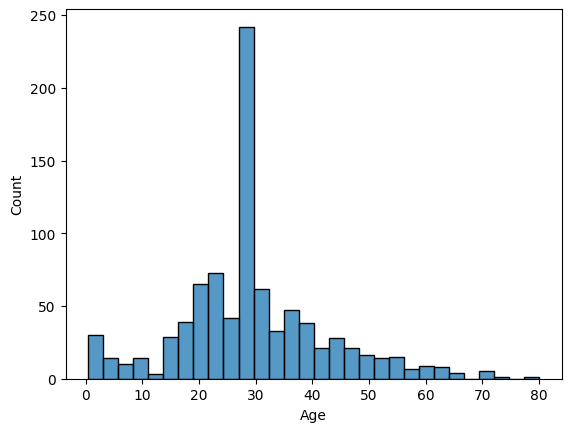

In [ ]:
sns.histplot(data=titanic, x="Age")

The boxplot confirms a fairly tight interquartile range (roughly 20–38), with several outliers on the higher end

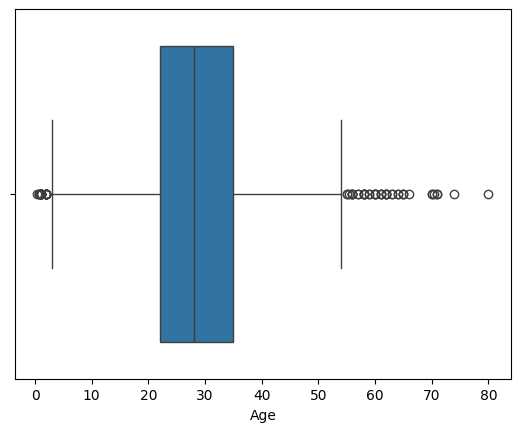

In [ ]:
sns.boxplot(x=titanic["Age"])
plt.show()

Survivors are noticeably concentrated at lower ages and higher fares compared to non-survivors, suggesting both youth and wealth were associated with survival.

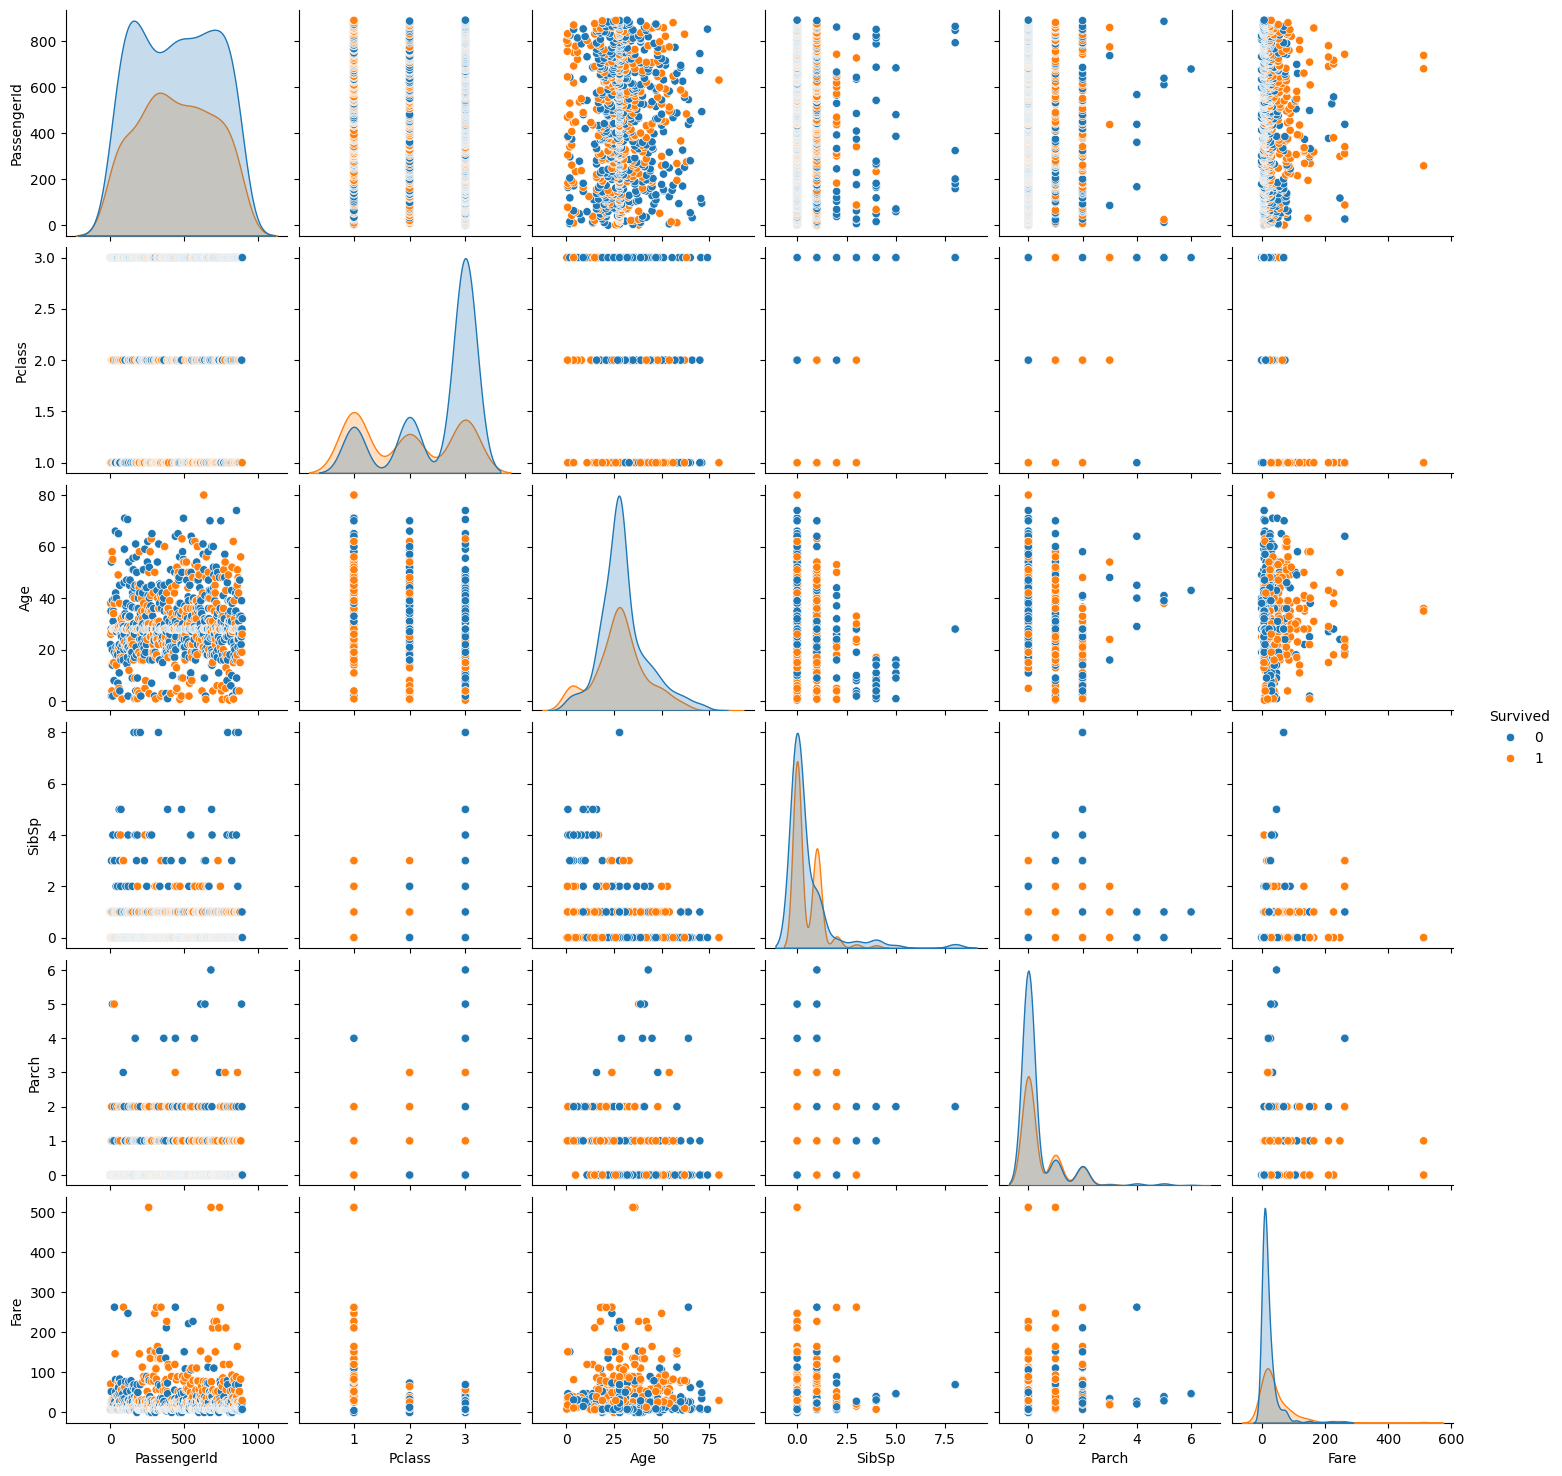

In [ ]:
sns.pairplot(data=titanic,hue='Survived')
plt.show()

Shows heavy outliers above ~100, consistent with the skew seen in the histogram

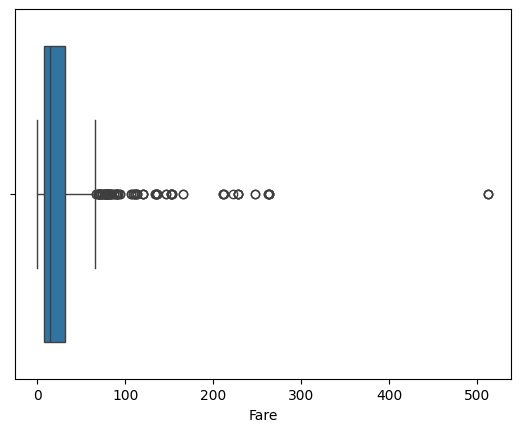

In [ ]:
sns.boxplot(x=titanic["Fare"])
plt.show()

**SUMMARY **
 Survival on the Titanic was strongly tied to passenger class and fare, with 1st class and higher-fare passengers surviving at noticeably higher rates than 3rd class passengers. Age also played a role, with younger passengers and children showing better survival odds than older adults. Fare distribution was heavily right-skewed, driven by a small number of high-paying 1st class travelers, while Age was closer to normally distributed with a slight right skew. Missing data was concentrated in Age (20%) and Cabin (77%), the latter of which was mostly dropped due to insufficient coverage, though its presence itself correlated with class and fare.